# Exploratory Data Analysis (EDA) of the data
This notebook performs some exploratory data analysis in preparation for data cleaning 

--- 
# Load Modules/Libraries

---

In [1]:
from importlib.metadata import version
from pathlib import Path

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

In [2]:
pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.4.4
pandas version: 3.0.2


--- 
# Retreieving the Data

---

In [3]:
# Data File constants
file_name = "heart.csv"
data_file_path = Path("./data") / file_name
print(data_file_path)
raw_df = pd.read_csv(data_file_path)

data/heart.csv


--- 
# EDA steps

---

#### raw_df.info()
Use the .info() method to gain a quick view of the data a quick summary

* 303 rows of data

* 14 columns - 13 features and a single target variable 
    * age (Dtype: int64): The age of the patient in years.
    * sex (Dtype: int64): Gender of the patient (0: female, 1: male).
    * cp (Dtype: int64): Type of chest pain (0-3).
    * trestbps (Dtype: int64): Resting blood pressure.
    * chol (Dtype: int64): Serum cholesterol (mg/dl).
    * fbs (Dtype: int64): Fasting blood sugar > 120 mg/dl.
    * restecg (Dtype: int64): Resting electrocardiographic results.
    * thalach (Dtype: int64): Maximum heart rate achieved.
    * exang (Dtype: int64): Exercise induced angina.
    * oldpeak (Dtype: float64): ST depression induced by exercise relative to rest
    * slope (Dtype: int): Slope of peak exsercis ST
    * ca (Dtype: int): Major vessels (0-4) - gold standard predictor
    * thal (Dtype: int): Thalassemia types
    * target (Dtype: int64): Heart Disease Status (0: Does not have heart disease , 1: Has Heart Disease)

* We do not see any missing values 

In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
raw_df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Core Data Checks
https://www.kaggle.com/code/abolfazluk/ai-powered-heart-health-prediction-uci-dataset/notebook
* Check number of unique values
* Checking for duplicates
* Check missing values
* Identify continuous features 
* Identify discrete features
* Look for any imbalances in the discrete Features and especially the target variable.
* Check for outliers in continuous features
* Perform Pearson corrleation analysis

In [6]:
# Checking for Unique Values per feature
raw_df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [7]:
def generate_ranges_or_uniques(df:pd.DataFrame) -> dict[str, list[int]]:
    """
    Extracts numerical ranges or counts of unique values for a given column.
    
    Args:
        df (pd.DataFrame): the heart pandas dataframe
        
    Returns:
        result(dict[str, list[int]]): A dictionary where keys represent the feature/metric/target name and values are lists of strings.
    """
    result = dict()

    for col_name in df.columns:
        unique_values =  sorted(raw_df[col_name].unique())

        
        if len(unique_values) <= 6:
            result[col_name] = [0,  len(unique_values)]
        else:
            result[col_name] = [1, min(unique_values), max(unique_values)]
    
    return result

In [8]:
def print_ranges_or_uniques(uniques:dict[str, list[int]]) -> list[str]:
    """
    Print numerical ranges or counts of unique values for a given column.
    
    Args:
       uniques(dict[str, list[int]]): the heart pandas dataframe
        
    Returns:
        result (list[str]): List of strings showing the ranges
    """
    result_list: list[str] = []
    for key, value in uniques.items():
        if uniques[key][0] == 0: 
            result_list.append(f"{key}: Range: {list(range(0,uniques[key][1]))}")
        else:
            result_list.append(f"{key}: Range: {uniques[key][1]} - {uniques[key][2]}")
    return result_list

In [9]:
range_and_unique_dict = generate_ranges_or_uniques(raw_df)
print(print_ranges_or_uniques(range_and_unique_dict))

['age: Range: 29 - 77', 'sex: Range: [0, 1]', 'cp: Range: [0, 1, 2, 3]', 'trestbps: Range: 94 - 200', 'chol: Range: 126 - 564', 'fbs: Range: [0, 1]', 'restecg: Range: [0, 1, 2]', 'thalach: Range: 71 - 202', 'exang: Range: [0, 1]', 'oldpeak: Range: 0.0 - 6.2', 'slope: Range: [0, 1, 2]', 'ca: Range: [0, 1, 2, 3, 4]', 'thal: Range: [0, 1, 2, 3]', 'target: Range: [0, 1]']


#### The Number of Unique Values per Feature were as Expected

* 14 columns - 13 features and a single target variable - Unique values
    * age (Dtype: int64): The age of the patient in years -- we see 41 different ages
    * sex (Dtype: int64): Gender of the patient (0: female, 1: male). - as expected we see only two types female or male
    * cp (Dtype: int64): Type of chest pain (0-3). - as expected we see at least 4 possible values
    * trestbps (Dtype: int64): Resting blood pressure. -- we see 49 different values
    * chol (Dtype: int64): Serum cholesterol (mg/dl). -- we see 152 unique values 
    * fbs (Dtype: int64): Fasting blood sugar > 120 mg/dl.-- we see only two unique values
    * restecg (Dtype: int64): Resting electrocardiographic results. -- we see 3 different types of values
    * thalach (Dtype: int64): Maximum heart rate achieved. -- we see 91 possible values 
    * exang (Dtype: int64): Exercise induced angina. -- we see two possible types of values
    * oldpeak (Dtype: float64): ST depression induced by exercise relative to rest -- we see 40 unique values
    * slope (Dtype: int): Slope of peak exsercis ST - we see three unique values
    * ca (Dtype: int): Major vessels (0-4) - we see four unique values
    * thal (Dtype: int): Thalassemia types - we see that there are four unique types
    * target (Dtype: int64): Heart Disease Status (0: Does not have heart disease , 1: Has Heart Disease) - we see two unique values


In [10]:
# Checking for duplicates
raw_df.duplicated().sum()

np.int64(1)

#### There were no rows duplicated!

<Axes: >

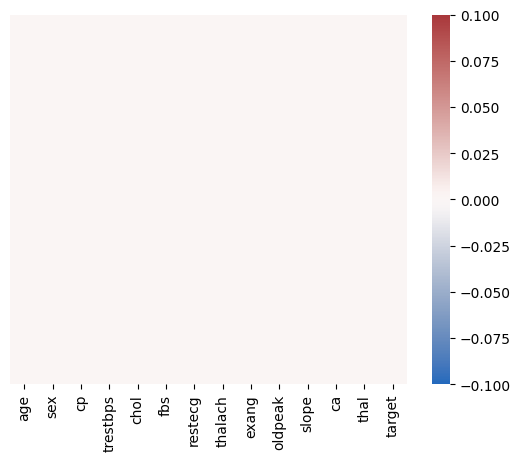

In [11]:
# Check Missing Values - using a visualization
sns.heatmap(raw_df.isnull(), yticklabels=False, cbar=True, cmap='vlag')

##### We had no missing values for all of the features and the target variable

In [12]:
# Identify Continuous and Discrete/Categorical Features 
continuous_features: list[str] = list()
discreate_features: list[str] = list()
for key, value in range_and_unique_dict.items():
        if range_and_unique_dict[key][0] == 0: 
                discreate_features.append(key)
        else:
                continuous_features.append(key)

print("Contious Features: ", continuous_features)
print("Discrete Features: ", discreate_features)

Contious Features:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Discrete Features:  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


#### Identify Continuous Features 

Continous Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#### Identify Discreate Features

Discrete Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [13]:
# Look for any Imbalances in the Discrete Features and Especially the Target Value.
def check_for_imbalances(col_name:str, df:pd.DataFrame) -> dict[str,int]:
    """
    Check discrete features to determine what features have imbalances
    
    Args:
       col_name (str): column name of the dataframe
       df (pd.DataFrame): the heart dataframe 
        
    Returns:
        dict[str,int]: Dictionary of the counts of each discrete features contents
    """
    # Extract value counts and convert directly
    return df[col_name].value_counts().to_dict()

In [14]:
imbalance_dict: dict[str, dict[str,int]] = dict()
for col_name in discreate_features:
    imbalance_dict[col_name] = check_for_imbalances(col_name, raw_df)

In [15]:
imbalance_dict

{'sex': {1: 207, 0: 96},
 'cp': {0: 143, 2: 87, 1: 50, 3: 23},
 'fbs': {0: 258, 1: 45},
 'restecg': {1: 152, 0: 147, 2: 4},
 'exang': {0: 204, 1: 99},
 'slope': {2: 142, 1: 140, 0: 21},
 'ca': {0: 175, 1: 65, 2: 38, 3: 20, 4: 5},
 'thal': {2: 166, 3: 117, 1: 18, 0: 2},
 'target': {1: 165, 0: 138}}

### Imbalance Analysis

##### The **Target** looks well-balanced: `target': {1: 165, 0: 138}}`

There are 303 total observations of 165 were positive for heart disease (target =1), and 138 did not have heart disease (target=0).
* 54% (target = 1)
* 46% (target = 0)

##### Features have imbalances
These imbalances can be problematic. Take for instance `ca` is gold standard predictor for heart disease and such imbalances can 
make the model biased toward the majority classes in each feature. 

For features like `ca` (where values 3 and 4 have very low counts) or `restecg` (where 2 only has 4 instances), Machine Learning models will not have enough data to learn their patterns.

* CA - Major Vessels (0-4) - Recall this is a gold standard predictor
    * (CA = 0) 175 out of 303 ~ 58%
    * (CA = 1) 65 out of 303 ~ 21%
    * (CA = 2) 38 out of 303 ~ 12%
    * (CA = 3) 20 out of 303 ~ 7%
    * (CA = 4) 5 out of 303 ~ 2%

* CP - Chest Pain Type (0-3) 
    * (CP = 0) 143 out of 303 ~ 47%
    * (CP = 1) 50 out of 303 ~ 16%
    * (CP = 2) 87 out of 303 ~ 29%
    * (CP = 3) 23 out of 303 ~ 8%

* EXANG - Exercise Induced Angina, Exercise Pain = Major Flag
    * (EXANG = 0) 204 out of 303 ~ 67% (Excerise Pain Does Not Occur)
    * (EXANG = 1) 99 out of 303 ~ 33% (Exercise Pain Occurs)

* FBS - Fasting Blood Sugar - 2 types 
    * (FBS = 0) 258 out of 303 ~ 85% Fasting blood sugar <= 120 mg/dl
    * (FBS = 1) 45 out of 303 ~ 15% Fasting blood sugar > 120 mg/dl

* RESTECG - Resting ECG results - 3 types 
    * (RESTECG = 0) 147 out of 303 ~ 49% 
    * (RESTECG = 1) 152 out of 303 ~ 50% 
    * (RESTECG = 2) 4 out of 303 ~ 1% 

* SEX - Gender 0 = Male, 1 = Female
    * (SEX = 0) 96 out of 303 ~ 32%  (Males)
    * (SEX = 1) 207 out of 303 ~ 68% (Females)

* Slope - Slope of Peak Excersise - ST Flat/Steep Slope (Down) Patterns = Disease
    * (SLOPE = 0) 21 out of 303 ~ 7%  Normal Slope - healthy Heart
    * (SLOPE = 1) 140 out of 303 ~ 46% Flat Slope - suggesting Poetential Heart Disease
    * (SLOPE = 2) 142 out of 303 ~ 47% Steep Slope - indicates severe cardiovascular issues

* THAL - Thalassemia (0-3) - 4 types
    * (THAL = 0) 2 out of 303 ~ 1%
    * (THAL = 1) 18 out of 303 ~ 5%
    * (THAL = 2) 166 out of 303 ~ 55%
    * (THAL = 3) 117 out of 303 ~ 39%

---
#### Now to Apply Imbalance Strategies

##### Group Rare Categories
Features like `ca` (values 3 and 4) and `thal` (value 0) have very low counts. We can merge these into existing logical groups. By grouping the `ca` and `thal` outliers, you prevent the model from learning "noise" from categories with only 2 or 5 samples.

##### Stratified Splitting
Stratified splitting is crucial for small, imbalanced datasets. It ensures the target distribution (and implicitly the rare feature distributions) remains the same in both sets.

Using stratify=y in the train_test_split function ensures that your model evaluation is based on a representative sample of your data.


##### Encoding and Scaling
After splitting, encode categorical variables and scale continuous ones to prevent data leakage. In machine learning, if you encode or scale your entire dataset before splitting it into training and testing sets, the "testing" information "leaks" into the "training" process.


##### Avoiding Leakage 
When you use a `StandardScaler`, it calculates the mean and standard deviation of the data to shift everything to a center of 0.

* **The Leak**: If you scale the whole dataset first, the scaler uses the values from the test set to calculate that mean.

* **The Consequence**: Your training data now "knows" the average value of the test data. The model is no longer being tested on truly "unseen" data because the test set's distribution influenced the training set's values.

* **The Fix**: Always fit the scaler on the Train set only, then transform both the Train and Test sets using those training parameters.


**Encoding Leakage (The "Missing Category" Problem)**

Encoding (especially One-Hot Encoding) creates new columns based on the unique categories present in a feature.

* **The Leak**: If you encode the whole dataset, you might create columns for categories that only exist in the test set.

* **The Consequence**: During training, the model might see a column that stays 0 for every single training row but has 1s in the test set. This can lead to dimensionality mismatches or the model making assumptions about a category it never actually "learned" from.

* **The Fix**: Encode after the split. If the test set has a category the training set didn't have, a robust pipeline will simply ignore it or map it to an "Unknown" column.


**Target Leakage (The Golden Rule)**

While not directly about scaling, the most dangerous leakage happens if any feature is calculated using the target variable.

* Example: If you calculated the "Average Heart Rate for people with Heart Disease" and added that as a feature for every row, your model would simply "cheat" by looking at that average to guess the target.

In [16]:
# Assuming 'df' is your existing DataFrame
def mitigate_feature_imbalance(df:pd.DataFrame) -> pd.DataFrame:
    """
        Check discrete features to determine what features have imbalances
        
        Args:
        col_name (str): column name of the dataframe
        df (pd.DataFrame): the heart dataframe 
            
        Returns:
            dict[str,int]: Dictionary of the counts of each discrete features contents
    """
    # Merge 'ca' values 3 and 4 into a single category '3+' (represented as 3)
    df['ca'] = df['ca'].replace({4: 3})
    
    # Map 'thal' 0 (rare/potential error) to the most common value (2)
    df['thal'] = df['thal'].replace({0: 2})
    
    # Group 'restecg' 2 with 1 if it remains too sparse for your model
    df['restecg'] = df['restecg'].replace({2: 1})
    
    return df

raw_df = mitigate_feature_imbalance(raw_df)


### Check on Outliers for the Continuous Features for Possible Cleaning

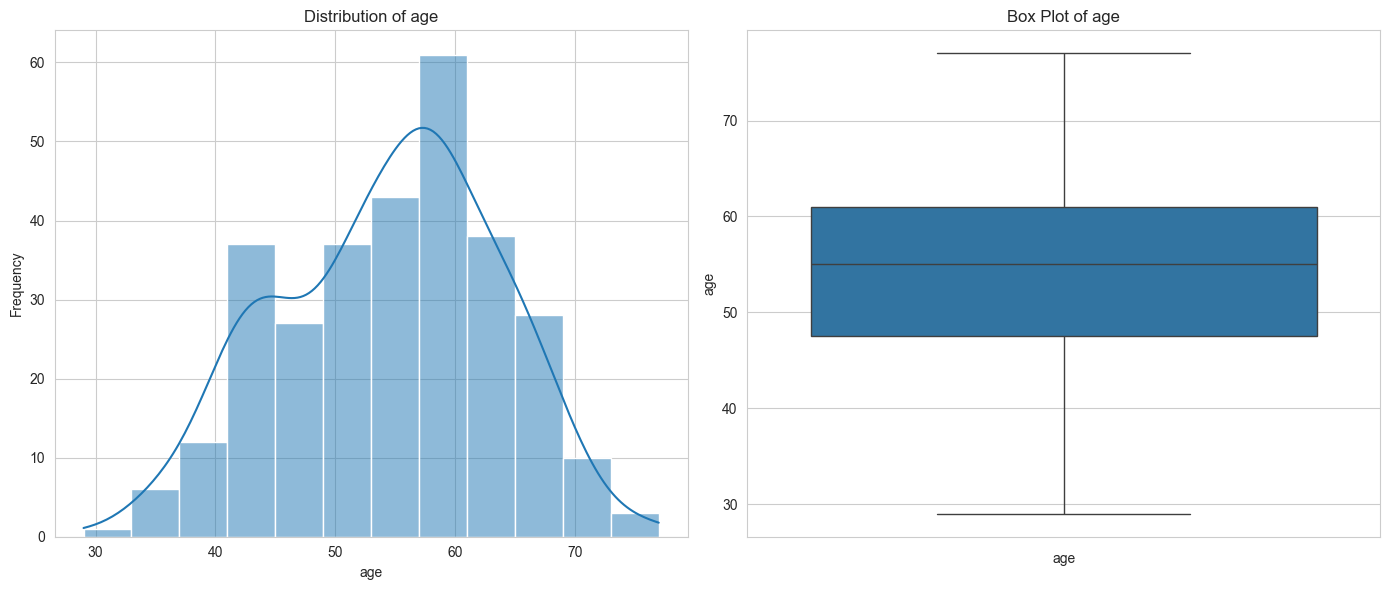

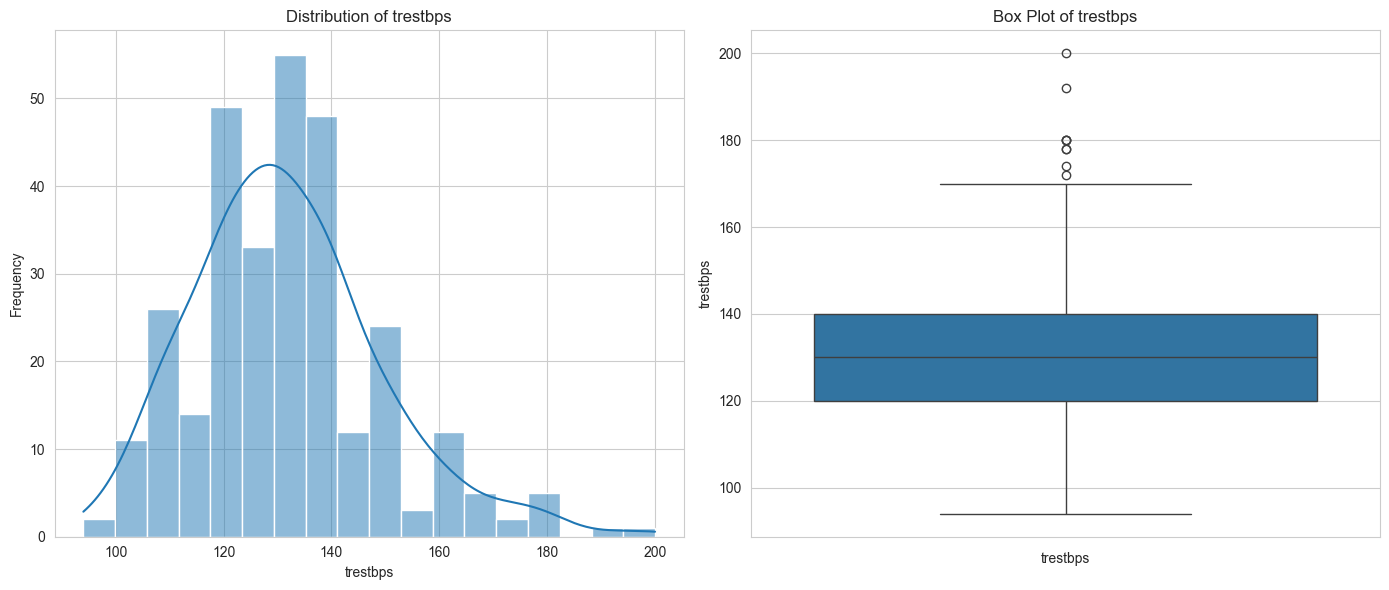

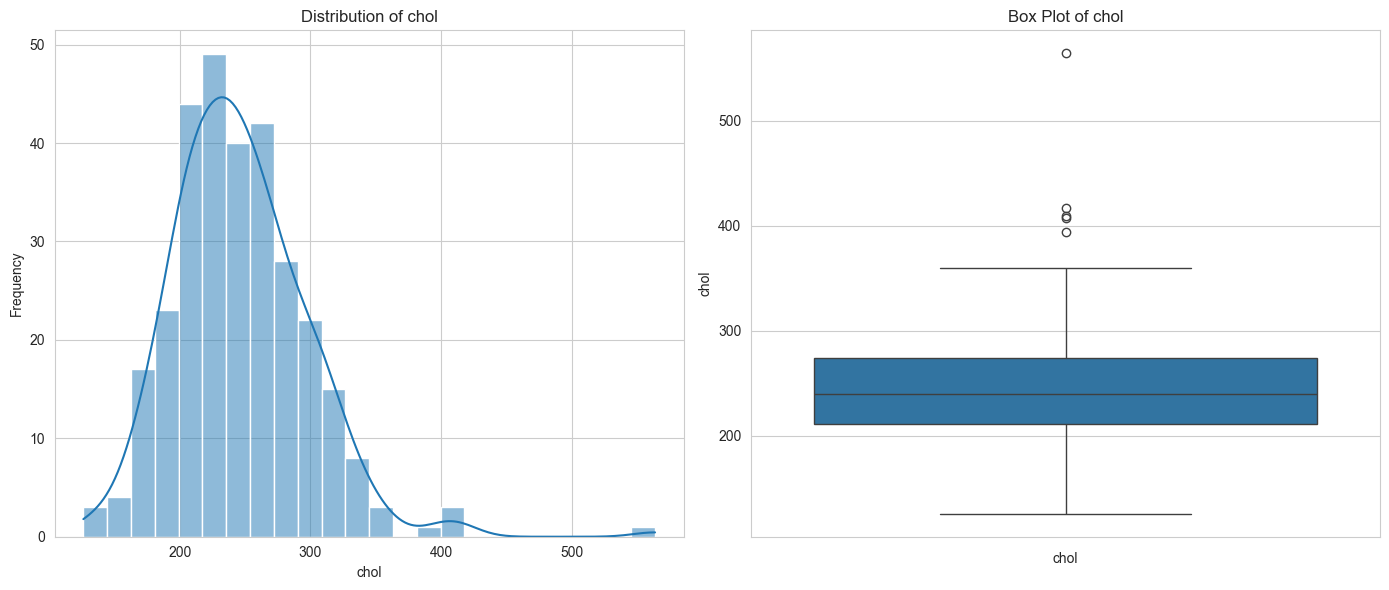

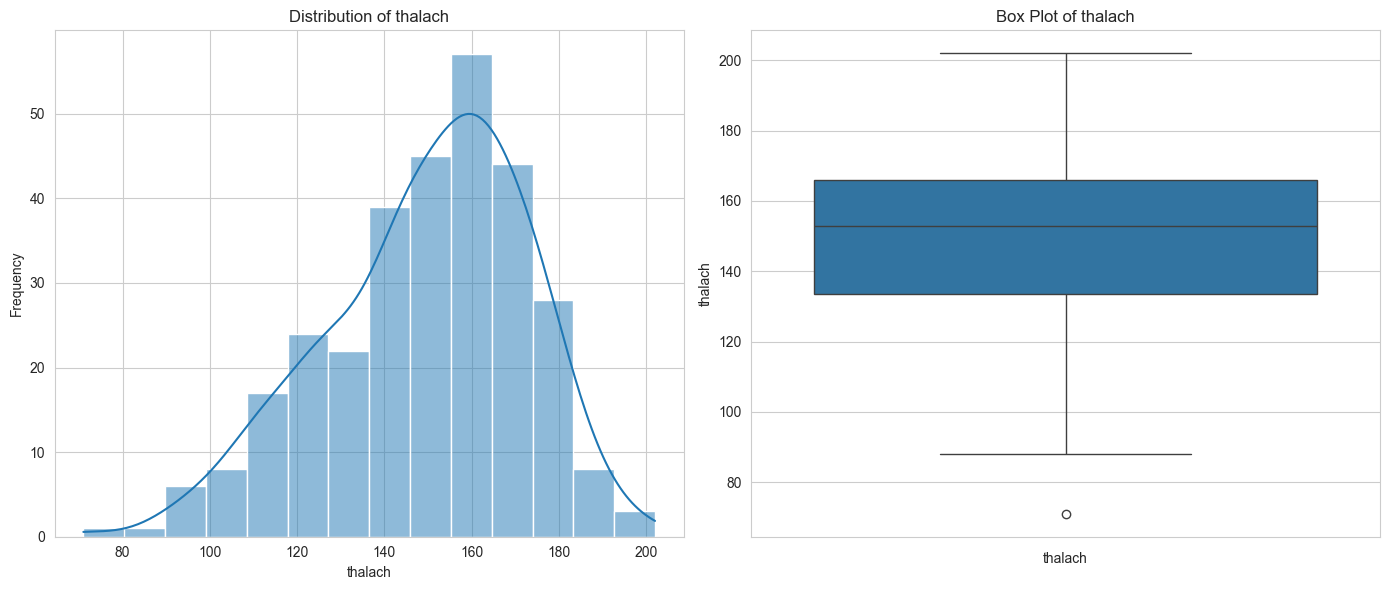

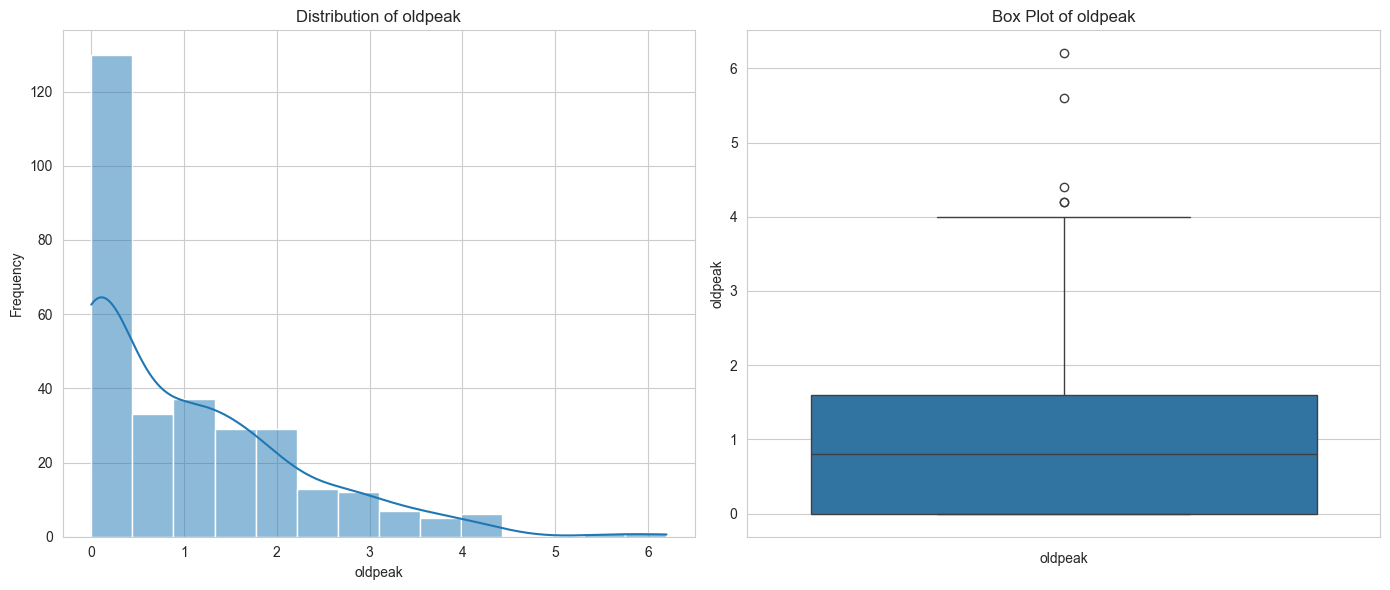

In [17]:
cols_to_viz = continuous_features

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create histograms and box plots for each feature
for column in cols_to_viz:
    plt.figure(figsize=(14, 6))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(raw_df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=raw_df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

---

### Applying Some Outlier Mitigation Strategies

##### Remove the extreme outlier for `CHOL` 
* There is an extreme outlier at 564

##### Remove the extreme outliers for `OLDPEAK` 
* There are extreme outliers at 6.2 mm and 5.6 mm


##### Remove the extreme outliers for `trestbps` 
* There are extreme outliers at 200 mmHg and 192 mmHG

In [18]:
# 1. Remove extreme outlier for CHOL (564)
df_cleaned = raw_df[~raw_df['chol'].isin([564])]

# 2. Remove extreme outliers for OLDPEAK (6.2, 5.6)
df_cleaned = raw_df[~raw_df['oldpeak'].isin([6.2, 5.6])]

# 3. Remove extreme outliers for trestbps (200, 192)
df_cleaned = raw_df[~raw_df['trestbps'].isin([200, 192])]


In [19]:
df_cleaned.info()# See we do not have the same number of rows as in raw_df

<class 'pandas.DataFrame'>
Index: 301 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       301 non-null    int64  
 1   sex       301 non-null    int64  
 2   cp        301 non-null    int64  
 3   trestbps  301 non-null    int64  
 4   chol      301 non-null    int64  
 5   fbs       301 non-null    int64  
 6   restecg   301 non-null    int64  
 7   thalach   301 non-null    int64  
 8   exang     301 non-null    int64  
 9   oldpeak   301 non-null    float64
 10  slope     301 non-null    int64  
 11  ca        301 non-null    int64  
 12  thal      301 non-null    int64  
 13  target    301 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.3 KB


### Perform Pearson Corrleation Analysis - Creating the Correlation Matrix

Visualize the correlation between numerical features to understand their relationships.


###### Result:

Clinical symptoms Chest Pain (`cp`) and Stress test indicators: Exercise Angina (`exang`) and `oldpeak` carry the highest predictive power for heart disease

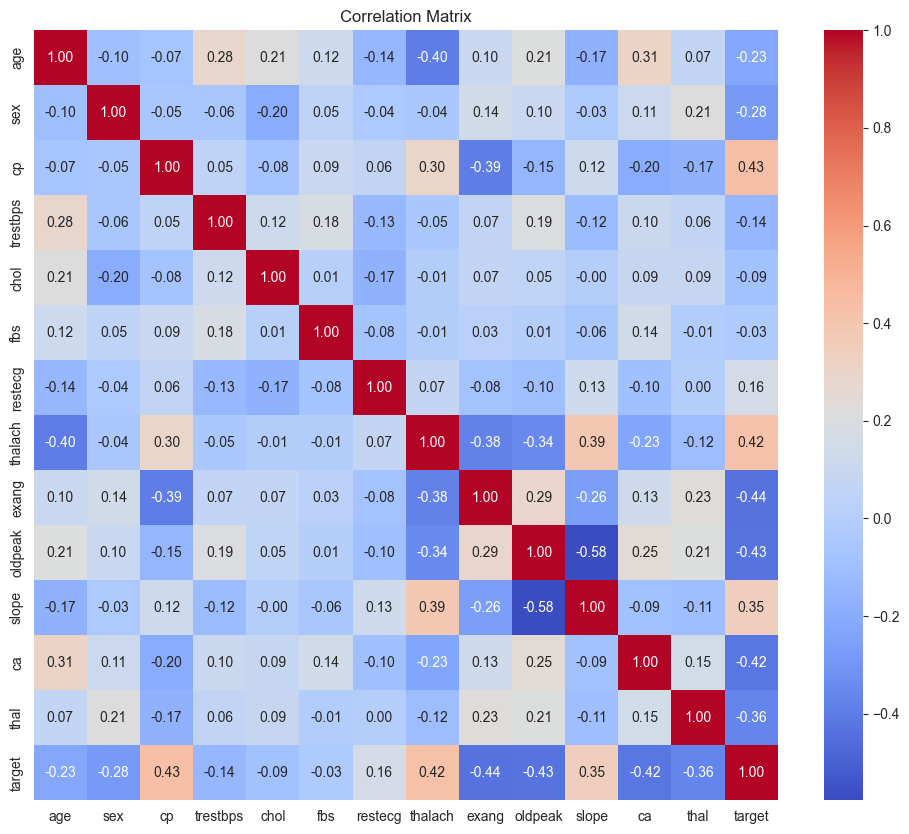

In [20]:
# Compute the correlation matrix
correlation_matrix = raw_df.corr(numeric_only=True)

# Use seaborn to visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

---
---

# Save the Cleaned Data as a New CSV


In [21]:
# Data File constants
clean_file_name = "cleaned_data.csv"
data_file_path = Path("data") / clean_file_name

# # Check if the target file already exists to avoid having to download it
if data_file_path.exists():
    print(f"{data_file_path} already exists. Skip creating the csv")
else:
    df_cleaned.to_csv(data_file_path, index=False)